## Issue #7, Notebook 7.2: Cumulative spend, capsule vs. trend-chasing

Simulates 5 years of spend under two strategies:
- **Trend-chasing:** Zara AU Basic Plain Knit Jumper (AU$65.95), purchased monthly, per the modal purchase-frequency band in Morgan & Birtwistle (2009), Table 3.
- **Capsule:** COS Belt-Detail Merino Wool Jumper (AU$225.00), replaced every 2.2 years, per WRAP (2012) *Valuing Our Clothes* average UK garment lifetime (general population baseline, not durable-specific, conservative for this side).

Both prices confirmed on-site, standard (non-sale) pricing, see `sources/cycle 2/issue-07/sources.md`.

## 1. Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = "../../../data/raw/cycle 2/issue-07"
PROCESSED_DIR = "../../../data/processed/cycle 2/issue-07"
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

## 2. Load brand palette

In [2]:
with open("../../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

## 3. Build the spend model

### 3.1 Define the sourced inputs

In [3]:
# prices sourced in native currency (AUD), see sources.md
CAPSULE_PRICE_AUD = 225.00       # COS Belt-Detail Merino Wool Jumper, Steel Blue
TRENDCHASE_PRICE_AUD = 65.95     # Zara AU Basic Plain Knit Jumper, Ink Blue

# AUD -> USD conversion, to match the FRED apparel-spend series (USD)
# Rate: 1 AUD = 0.7203 USD, Xe.com mid-market rate, 2026-09-04
AUD_TO_USD = 0.7203

CAPSULE_PRICE = round(CAPSULE_PRICE_AUD * AUD_TO_USD, 2)       # US$162.07
TRENDCHASE_PRICE = round(TRENDCHASE_PRICE_AUD * AUD_TO_USD, 2)  # US$47.50

# frequencies (see sources.md for full citations)
CAPSULE_REPLACE_YEARS = 2.2  # WRAP (2012), average UK garment lifetime
TRENDCHASE_PURCHASE_MONTHS = 1  # Morgan & Birtwistle (2009), Table 3, modal group

SIM_YEARS = 5
SIM_MONTHS = SIM_YEARS * 12

### 3.2 Build the monthly timeline

In [6]:
months = np.arange(0, SIM_MONTHS + 1)

# trend-chasing: a purchase every month, starting at month 0
trendchase_purchases = np.where(months % TRENDCHASE_PURCHASE_MONTHS == 0, TRENDCHASE_PRICE, 0.0)
trendchase_cumulative = np.cumsum(trendchase_purchases)

# capsule: a purchase at month 0, then every CAPSULE_REPLACE_YEARS*12 months
capsule_replace_months = CAPSULE_REPLACE_YEARS * 12
capsule_purchase_months = np.round(np.arange(0, SIM_MONTHS + 1, capsule_replace_months)).astype(int)
capsule_purchases = np.zeros(len(months))
capsule_purchases[capsule_purchase_months] = CAPSULE_PRICE
capsule_cumulative = np.cumsum(capsule_purchases)

df = pd.DataFrame({
    "month": months,
    "year": months / 12,
    "trendchase_cumulative_usd": trendchase_cumulative,
    "capsule_cumulative_usd": capsule_cumulative,
})

df.tail()

,month,year,trendchase_cumulative_usd,capsule_cumulative_usd
56,56,4.666667,2707.5,486.21
57,57,4.750000,2755.0,486.21
58,58,4.833333,2802.5,486.21
59,59,4.916667,2850.0,486.21
60,60,5.000000,2897.5,486.21


In [5]:
# save the processed data
df.to_csv(f"{PROCESSED_DIR}/cumulative_spend_5yr.csv", index=False)

## 4. Plot

### 4.1 Plain exploratory plot

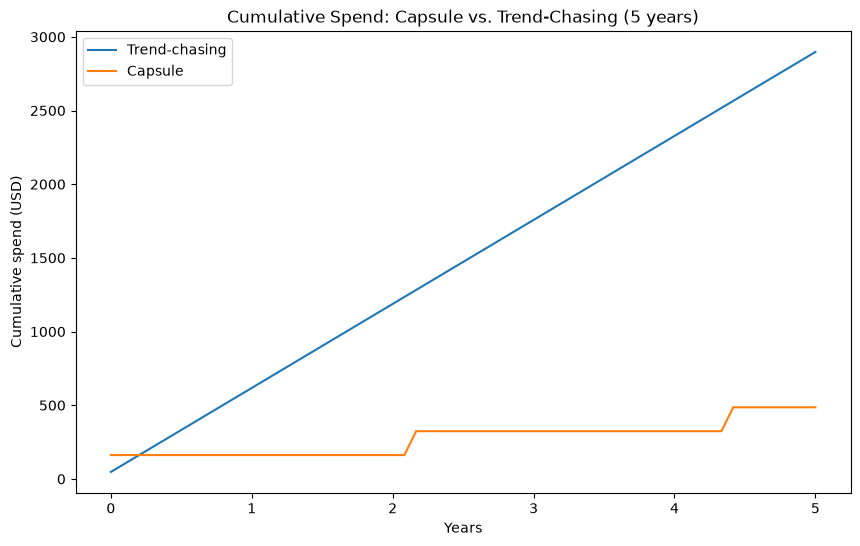

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df["year"], df["trendchase_cumulative_usd"], label="Trend-chasing")
ax.plot(df["year"], df["capsule_cumulative_usd"], label="Capsule")
ax.set_title("Cumulative Spend: Capsule vs. Trend-Chasing (5 years)")
ax.set_xlabel("Years")
ax.set_ylabel("Cumulative spend (USD)")
ax.legend()

plt.show()

In [10]:
# save the exploratory plot to sources
fig.savefig("../../../sources/cycle 2/issue-07/7.2-cumulative-spend-raw.png", dpi=150, bbox_inches="tight")

### 4.2 Branded version

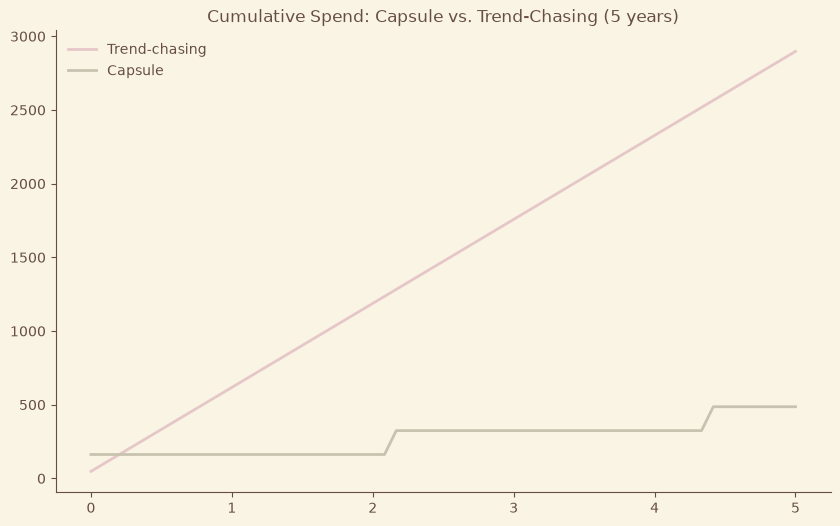

In [12]:
os.makedirs("../../../content/posts/cycle 2/issue-07/exports", exist_ok=True)

with plt.rc_context({
    "font.family": "sans-serif",  # swap for Neue Machina / Libre Baskerville per slide use
    "axes.edgecolor": COCOA,
    "text.color": COCOA,
    "axes.labelcolor": COCOA,
    "xtick.color": COCOA,
    "ytick.color": COCOA,
}):
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    ax2.plot(df["year"], df["trendchase_cumulative_usd"], color=DUSTY, linewidth=2, label="Trend-chasing")
    ax2.plot(df["year"], df["capsule_cumulative_usd"], color=SAGE, linewidth=2, label="Capsule")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.set_facecolor(CREAM)
    fig2.patch.set_facecolor(CREAM)
    ax2.set_title("Cumulative Spend: Capsule vs. Trend-Chasing (5 years)")
    ax2.legend(frameon=False)

    plt.show()

In [13]:
# save the branded version to content/posts in the exports folder
fig2.savefig("../../../content/posts/cycle 2/issue-07/exports/7.2a-cumulative-spend-branded.png", dpi=150, bbox_inches="tight")

### 4.3 Export sample for Canva

In [15]:
# yearly checkpoints (every 12 months) for manual entry into Canva's chart element
sparse = df[df["month"] % 12 == 0]
sparse

,month,year,trendchase_cumulative_usd,capsule_cumulative_usd
0,0,0.0,47.5,162.07
12,12,1.0,617.5,162.07
24,24,2.0,1187.5,162.07
36,36,3.0,1757.5,324.14
48,48,4.0,2327.5,324.14
60,60,5.0,2897.5,486.21


In [16]:
# save it in the process data folder
sparse.to_csv(f"{PROCESSED_DIR}/cumulative_spend_yearly_sample.csv", index=False)
